# Final ML Models Comparison

# step1 - loading everything

In [13]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    classification_report, confusion_matrix
)

# Load models
lgb_model = joblib.load("best_lgb_calibrated.pkl")
xgb_model = joblib.load("xgb_tuned.pkl")
rf_model  = joblib.load("rf_calibrated.pkl")
le        = joblib.load("label_encoder.pkl")

# Reload raw data and rebuild eval set from scratch
train_df = pd.read_csv("train_dataset_prepared.csv")

le_fresh = joblib.load("label_encoder.pkl")
y_all = le_fresh.fit_transform(train_df["slice Type"])

clean_cols = ["Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"]

def engineer_features(df):
    df = df.copy()
    df["delay_x_loss"]   = df["Packet delay"] * df["Packet Loss Rate"]
    df["delay_per_loss"] = df["Packet delay"] / (df["Packet Loss Rate"] + 1e-6)
    df["category_delay"] = df["LTE/5g Category"] * df["Packet delay"]
    df["log_packet_loss"]  = np.log1p(df["Packet Loss Rate"])
    df["log_packet_delay"] = np.log1p(df["Packet delay"])
    df["delay_bin"] = pd.cut(
        df["Packet delay"],
        bins=[0, 50, 150, 200, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)
    return df

X_all = engineer_features(train_df[clean_cols].copy())

# Recreate the exact same 3-way split using same random_state
from sklearn.model_selection import train_test_split

X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)
X_cal, X_eval, y_cal, y_eval = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# For XGB/LGB — they were trained WITHOUT delay_bin
# so we need two versions of X_eval
X_eval_rf  = X_eval.copy()                        # with delay_bin
X_eval_xgb = X_eval.drop(columns=["delay_bin"])   # without delay_bin

class_names = [f"Slice {le.inverse_transform([i])[0]}" for i in range(3)]
print(f"Eval set size: {len(y_eval)}")
print(f"RF eval features:      {X_eval_rf.columns.tolist()}")
print(f"XGB/LGB eval features: {X_eval_xgb.columns.tolist()}")

Eval set size: 1344
RF eval features:      ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category', 'delay_x_loss', 'delay_per_loss', 'category_delay', 'log_packet_loss', 'log_packet_delay', 'delay_bin']
XGB/LGB eval features: ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category', 'delay_x_loss', 'delay_per_loss', 'category_delay', 'log_packet_loss', 'log_packet_delay']


# step2 - Compute all metrics

In [14]:
models = {
    "Random Forest": (rf_model,  X_eval_rf),
    "XGBoost":       (xgb_model, X_eval_xgb),
    "LightGBM":      (lgb_model, X_eval_xgb),
}

all_probas = {}
all_preds  = {}
results    = []

print(f"{'Model':<20} {'AUC':>8} {'LogLoss':>10} {'Accuracy':>10} {'Brier S1':>10} {'Brier S2':>10} {'Brier S3':>10}")
print("-" * 80)

for name, (model, X_ev) in models.items():
    proba = model.predict_proba(X_ev)
    pred  = proba.argmax(axis=1)
    all_probas[name] = proba
    all_preds[name]  = pred

    auc = roc_auc_score(y_eval, proba, multi_class='ovr', average='macro')
    ll  = log_loss(y_eval, proba)
    acc = (pred == y_eval).mean()
    bs  = [brier_score_loss((y_eval == i).astype(int), proba[:, i]) for i in range(3)]

    results.append({
        "Model": name, "AUC": auc, "LogLoss": ll, "Accuracy": acc,
        "Brier_S1": bs[0], "Brier_S2": bs[1], "Brier_S3": bs[2],
    })
    print(f"{name:<20} {auc:>8.4f} {ll:>10.4f} {acc:>10.4f} {bs[0]:>10.4f} {bs[1]:>10.4f} {bs[2]:>10.4f}")

results_df = pd.DataFrame(results).set_index("Model")

winner = results_df["LogLoss"].idxmin()
print(f"\n Best model by Log-loss: {winner}")
print(f"   AUC={results_df.loc[winner,'AUC']:.4f}  "
      f"LogLoss={results_df.loc[winner,'LogLoss']:.4f}  "
      f"Accuracy={results_df.loc[winner,'Accuracy']:.4f}")

Model                     AUC    LogLoss   Accuracy   Brier S1   Brier S2   Brier S3
--------------------------------------------------------------------------------
Random Forest          0.9947     0.0790     0.9427     0.0287     0.0287     0.0000
XGBoost                0.9947     0.0783     0.9397     0.0279     0.0279     0.0000
LightGBM               0.9937     0.0840     0.9323     0.0297     0.0297     0.0000

 Best model by Log-loss: XGBoost
   AUC=0.9947  LogLoss=0.0783  Accuracy=0.9397


# step 3 - Bar chart comparison

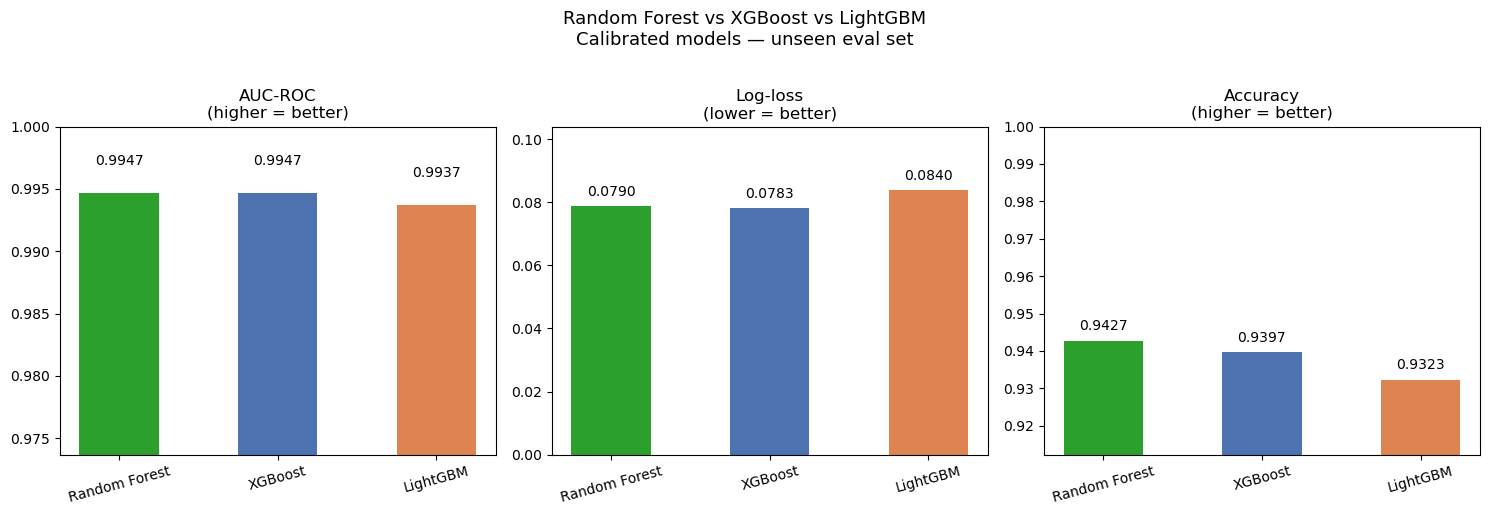

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#2ca02c", "#4C72B0", "#DD8452"]  # green=RF, blue=XGB, orange=LGB
model_names = results_df.index.tolist()

metrics = [
    ("AUC",      "AUC-ROC",   "higher = better", "max"),
    ("LogLoss",  "Log-loss",  "lower = better",  "min"),
    ("Accuracy", "Accuracy",  "higher = better", "max"),
]

for ax, (col, label, note, better) in zip(axes, metrics):
    vals = results_df[col].values
    bars = ax.bar(model_names, vals, color=colors, width=0.5)
    if better == "max":
        ax.set_ylim(vals.min() - 0.02, 1.0)
    else:
        ax.set_ylim(0, vals.max() + 0.02)
    ax.set_title(f"{label}\n({note})")
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{val:.4f}", ha='center', va='bottom', fontsize=10)

plt.suptitle("Random Forest vs XGBoost vs LightGBM\nCalibrated models — unseen eval set",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# step 4 - Confusion matrices side by side

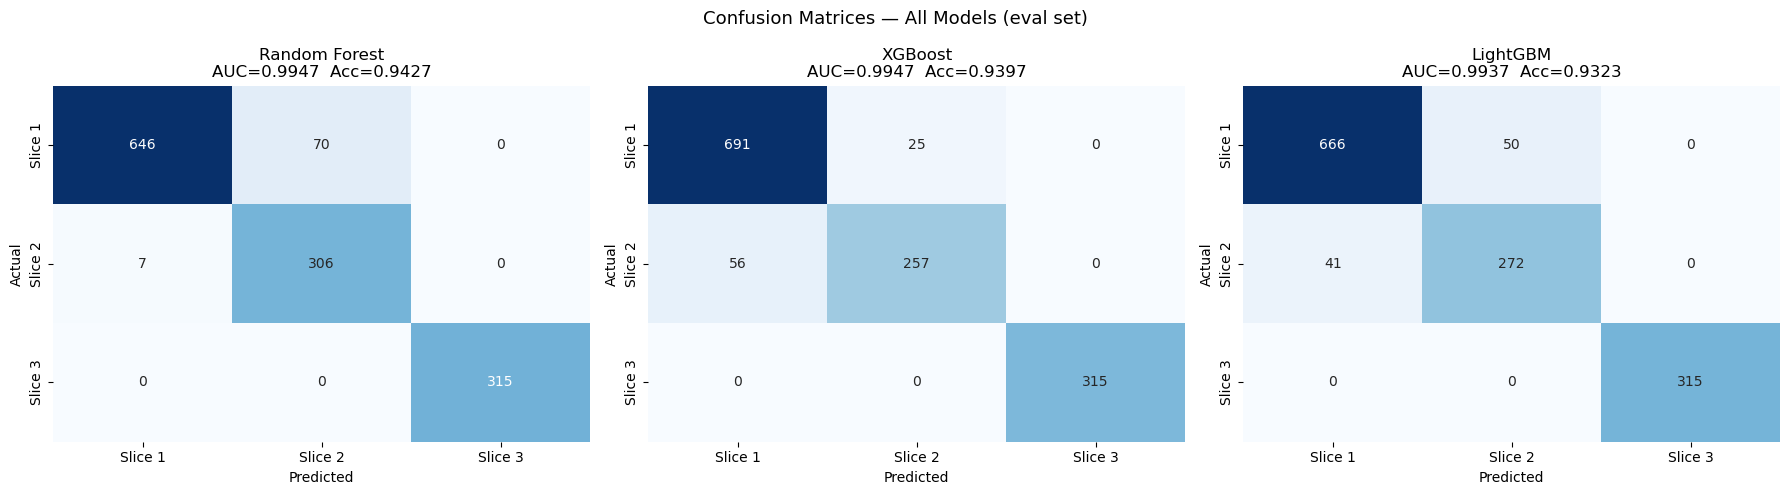

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_eval, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax, cbar=False)
    auc = results_df.loc[name, "AUC"]
    acc = results_df.loc[name, "Accuracy"]
    ax.set_title(f"{name}\nAUC={auc:.4f}  Acc={acc:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models (eval set)", fontsize=13)
plt.tight_layout()
plt.show()

# step 5 - Per-class classification reports

In [17]:
for name, pred in all_preds.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_eval, pred, target_names=class_names))


  Random Forest
              precision    recall  f1-score   support

     Slice 1       0.99      0.90      0.94       716
     Slice 2       0.81      0.98      0.89       313
     Slice 3       1.00      1.00      1.00       315

    accuracy                           0.94      1344
   macro avg       0.93      0.96      0.94      1344
weighted avg       0.95      0.94      0.94      1344


  XGBoost
              precision    recall  f1-score   support

     Slice 1       0.93      0.97      0.94       716
     Slice 2       0.91      0.82      0.86       313
     Slice 3       1.00      1.00      1.00       315

    accuracy                           0.94      1344
   macro avg       0.95      0.93      0.94      1344
weighted avg       0.94      0.94      0.94      1344


  LightGBM
              precision    recall  f1-score   support

     Slice 1       0.94      0.93      0.94       716
     Slice 2       0.84      0.87      0.86       313
     Slice 3       1.00      1.00  

# step 6 - Risk score comparison

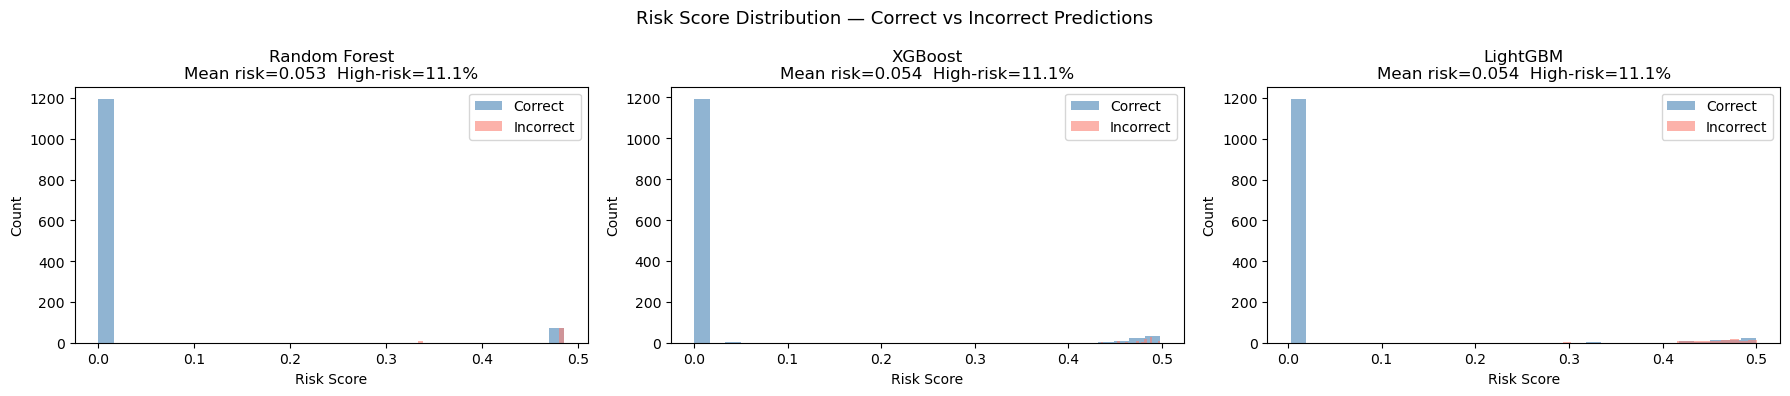

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (name, proba) in zip(axes, all_probas.items()):
    risk_scores = 1 - proba.max(axis=1)
    correct     = all_preds[name] == y_eval
    
    ax.hist(risk_scores[correct],  bins=30, alpha=0.6,
            label="Correct",   color="steelblue")
    ax.hist(risk_scores[~correct], bins=30, alpha=0.6,
            label="Incorrect", color="salmon")
    
    mean_risk  = risk_scores.mean()
    high_risk  = (risk_scores > 0.20).mean()
    ax.set_title(f"{name}\nMean risk={mean_risk:.3f}  High-risk={high_risk:.1%}")
    ax.set_xlabel("Risk Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Risk Score Distribution — Correct vs Incorrect Predictions",
             fontsize=13)
plt.tight_layout()
plt.show()

# step 7 - Final verdict

In [19]:
print("=" * 65)
print("  FINAL VERDICT")
print("=" * 65)

for _, row in results_df.reset_index().iterrows():
    print(f"\n{row['Model']}:")
    print(f"  AUC={row['AUC']:.4f}  LogLoss={row['LogLoss']:.4f}  Accuracy={row['Accuracy']:.4f}")
    print(f"  Brier: Slice1={row['Brier_S1']:.4f}  Slice2={row['Brier_S2']:.4f}  Slice3={row['Brier_S3']:.4f}")

winner = results_df["LogLoss"].idxmin()
runner = results_df["LogLoss"].drop(winner).idxmin()

print(f"""
WINNER:  {winner}
RUNNER-UP: {runner}

Justification:
- Log-loss is the primary metric because the objective is a calibrated
  PROBABILITY score, not just classification accuracy.
- Lower log-loss means the model's confidence scores are more trustworthy
  for SLA risk decisions.
- Slice 2 (URLLC) performance is the most critical differentiator —
  it has the strictest QoS requirements and the highest cost of misclassification.

Slice 2 recall comparison:""")

for name, pred in all_preds.items():
    report = classification_report(y_eval, pred,
                                   target_names=class_names,
                                   output_dict=True)
    s2_recall = report["Slice 2"]["recall"]
    print(f"  {name}: {s2_recall:.4f}")

  FINAL VERDICT

Random Forest:
  AUC=0.9947  LogLoss=0.0790  Accuracy=0.9427
  Brier: Slice1=0.0287  Slice2=0.0287  Slice3=0.0000

XGBoost:
  AUC=0.9947  LogLoss=0.0783  Accuracy=0.9397
  Brier: Slice1=0.0279  Slice2=0.0279  Slice3=0.0000

LightGBM:
  AUC=0.9937  LogLoss=0.0840  Accuracy=0.9323
  Brier: Slice1=0.0297  Slice2=0.0297  Slice3=0.0000

WINNER:  XGBoost
RUNNER-UP: Random Forest

Justification:
- Log-loss is the primary metric because the objective is a calibrated
  PROBABILITY score, not just classification accuracy.
- Lower log-loss means the model's confidence scores are more trustworthy
  for SLA risk decisions.
- Slice 2 (URLLC) performance is the most critical differentiator —
  it has the strictest QoS requirements and the highest cost of misclassification.

Slice 2 recall comparison:
  Random Forest: 0.9776
  XGBoost: 0.8211
  LightGBM: 0.8690
